
===== DATASET 1 (COMPANIES) =====
                             R2          CV_R2
Ridge Regression       0.982765  0.852 ± 0.182
Decision Tree          0.979055  0.890 ± 0.138
Random Forest (Tuned)  0.986953  0.915 ± 0.128
Gradient Boosting      0.954942  0.912 ± 0.129
XGBoost                0.968123  0.702 ± 0.452
Stacking Model         0.992536  0.597 ± 0.655

===== DATASET 2 (HOUSING) =====
                             R2          CV_R2
Ridge Regression       0.575816  0.553 ± 0.062
Decision Tree          0.599732  0.461 ± 0.116
Random Forest (Tuned)  0.806307  0.656 ± 0.078
Gradient Boosting      0.775643  0.670 ± 0.040
XGBoost                0.830137  0.649 ± 0.064
Stacking Model         0.834589  0.682 ± 0.036

Generating SHAP plot...


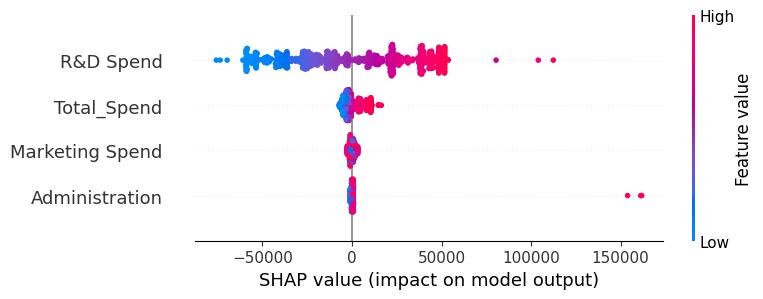

In [ ]:
import pandas as pd
import numpy as np
import joblib
import shap

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import clone

from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from xgboost import XGBRegressor

from sklearn.metrics import r2_score
from sklearn.datasets import fetch_california_housing

# =========================================
# 🔹 FUNCTION: FULL PIPELINE
# =========================================

def run_pipeline(X, y, dataset_name):

    print(f"\n===== {dataset_name} =====")

    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Hyperparameter tuning (Random Forest)
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [5, 10, None]
    }

    grid = GridSearchCV(
        RandomForestRegressor(random_state=42),
        param_grid,
        cv=5,
        scoring='r2'
    )
    grid.fit(X_train_scaled, y_train)
    best_rf = grid.best_estimator_

    # Models
    models = {
        "Ridge Regression": Ridge(alpha=1.0),
        "Decision Tree": DecisionTreeRegressor(max_depth=5),
        "Random Forest (Tuned)": best_rf,
        "Gradient Boosting": GradientBoostingRegressor(random_state=42),
        "XGBoost": XGBRegressor(random_state=42, verbosity=0)
    }

    results = {}

    # ---------------------------
    # Train + Evaluate Models
    # ---------------------------
    for name, model in models.items():

        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('model', clone(model))
        ])

        scores = cross_val_score(pipeline, X, y, cv=5, scoring='r2')
        cv_mean = scores.mean()
        cv_std = scores.std()

        results[name] = {
            "R2": r2_score(y_test, y_pred),
            "CV_R2": f"{cv_mean:.3f} ± {cv_std:.3f}"
        }

    # ---------------------------
    # Stacking Model (WITH CV)
    # ---------------------------
    stacking_model = StackingRegressor(
        estimators=[
            ('ridge', Ridge()),
            ('rf', best_rf),
            ('gb', GradientBoostingRegressor(random_state=42)),
            ('xgb', XGBRegressor(random_state=42, verbosity=0))
        ],
        final_estimator=Ridge()
    )

    # Train stacking
    stacking_model.fit(X_train_scaled, y_train)
    y_pred_stack = stacking_model.predict(X_test_scaled)

    # External CV for stacking
    stack_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', clone(stacking_model))
    ])

    scores = cross_val_score(stack_pipeline, X, y, cv=5, scoring='r2')
    cv_mean = scores.mean()
    cv_std = scores.std()

    results["Stacking Model"] = {
        "R2": r2_score(y_test, y_pred_stack),
        "CV_R2": f"{cv_mean:.3f} ± {cv_std:.3f}"
    }

    # Results DataFrame
    results_df = pd.DataFrame(results).T
    print(results_df)

    return best_rf, scaler, results_df


# =========================================
# 🔹 DATASET 1: COMPANIES
# =========================================

df1 = pd.read_csv("/content/drive/MyDrive/1000_Companies.csv")

df1['Total_Spend'] = (
    df1['R&D Spend'] +
    df1['Administration'] +
    df1['Marketing Spend']
)

features1 = ['R&D Spend', 'Administration', 'Marketing Spend', 'Total_Spend']
target1 = 'Profit'

X1 = df1[features1]
y1 = df1[target1]

best_rf1, scaler1, results_df1 = run_pipeline(X1, y1, "DATASET 1 (COMPANIES)")


# =========================================
# 🔹 DATASET 2: CALIFORNIA HOUSING
# =========================================

housing = fetch_california_housing()

X2 = pd.DataFrame(housing.data, columns=housing.feature_names)
y2 = housing.target

best_rf2, scaler2, results_df2 = run_pipeline(X2, y2, "DATASET 2 (HOUSING)")


# =========================================
# 🔹 SHAP EXPLAINABILITY (DATASET 1)
# =========================================

X1_scaled = scaler1.transform(X1)

explainer = shap.Explainer(best_rf1, X1_scaled)
shap_values = explainer(X1_scaled)

print("\nGenerating SHAP plot...")
shap.summary_plot(shap_values, X1)

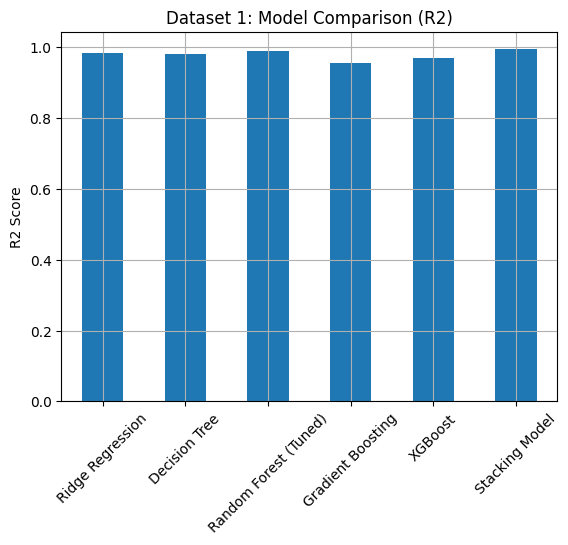

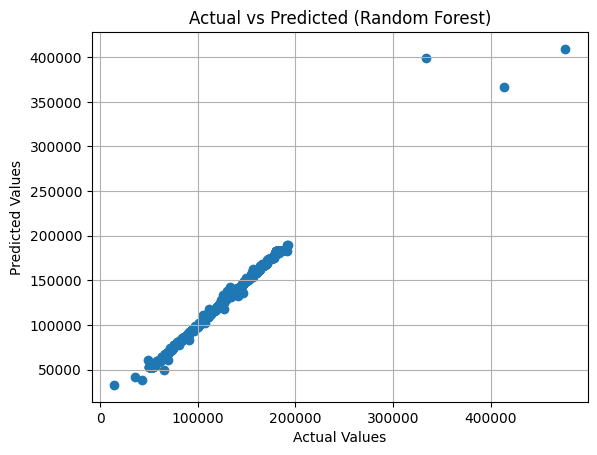

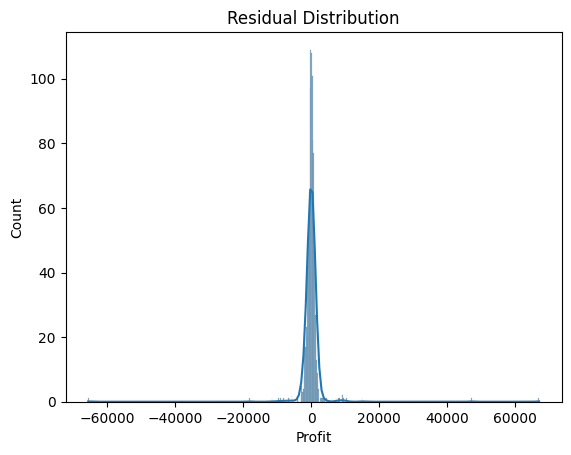

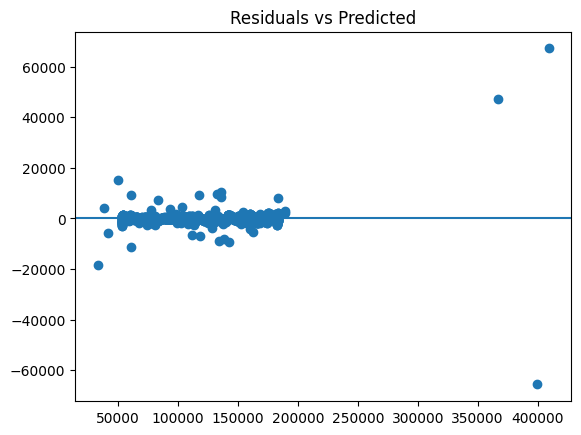

In [ ]:
# ==============================
# 🔥 UPGRADE 8: VISUALIZATIONS (FIXED)
# ==============================

import matplotlib.pyplot as plt
import seaborn as sns

def plot_model_comparison(results_df, title):
    plt.figure()
    results_df['R2'].astype(float).plot(kind='bar')
    plt.title(title)
    plt.ylabel("R2 Score")
    plt.xticks(rotation=45)
    plt.grid()
    plt.show()


# ✅ Use results_df1 (from pipeline return)
plot_model_comparison(results_df1, "Dataset 1: Model Comparison (R2)")


# -----------------------------------
# Actual vs Predicted
# -----------------------------------

y_pred_rf = best_rf1.predict(scaler1.transform(X1))

plt.figure()
plt.scatter(y1, y_pred_rf)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Random Forest)")
plt.grid()
plt.show()


# -----------------------------------
# Residuals
# -----------------------------------

residuals = y1 - y_pred_rf

plt.figure()
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

plt.figure()
plt.scatter(y_pred_rf, residuals)
plt.axhline(y=0)
plt.title("Residuals vs Predicted")
plt.show()

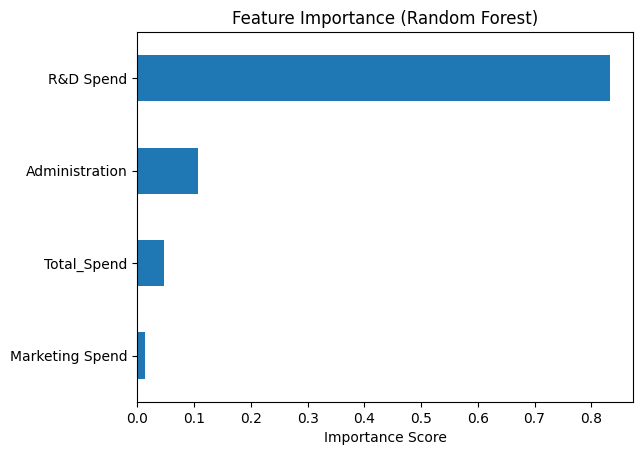

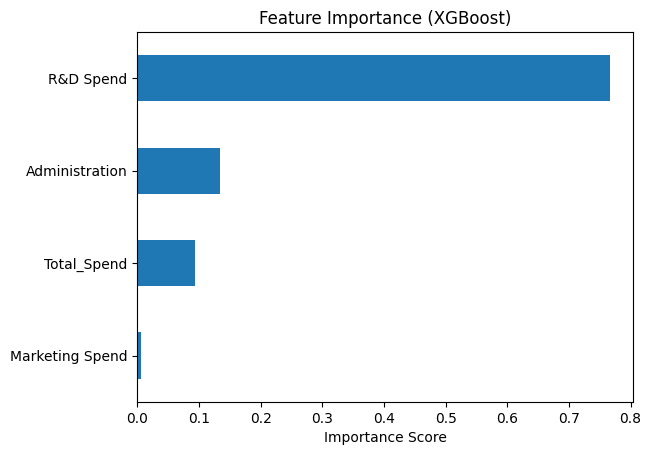

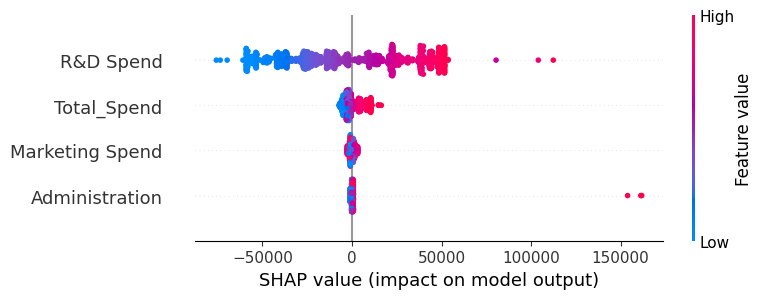

In [ ]:
# Feature Importance - Random Forest
import pandas as pd

feature_importance = pd.Series(best_rf1.feature_importances_, index=X1.columns)

plt.figure()
feature_importance.sort_values().plot(kind='barh')
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.show()

# Feature Importance - XGBoost
xgb_model = XGBRegressor(random_state=42)
xgb_model.fit(scaler1.transform(X1), y1)

importance = pd.Series(xgb_model.feature_importances_, index=X1.columns)

plt.figure()
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance Score")
plt.show()

# SHAP Summary Plot
import shap

X1_scaled = scaler1.transform(X1)

explainer = shap.Explainer(best_rf1, X1_scaled)
shap_values = explainer(X1_scaled)

shap.summary_plot(shap_values, X1)